# Ejercicio 5: Incorporacion de los datos de 2024

Valida que los archivos de 2024 descargados por `scripts/download_data.py` se incorporaron correctamente, que DuckDB consulta 2024 y 2026 de forma conjunta y que las consultas de los Ejercicios 3 y 4 siguen funcionando.

Las consultas estan en `sql/ejercicio5/`; la documentacion y las respuestas a las preguntas del ejercicio, en `docs/ejercicio5.md`.

In [1]:
import os
import re
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
DIR_SQL = Path("sql/ejercicio5")

con = duckdb.connect()
# Vistas del Ejercicio 4 (viajes, viajes_validos, zonas) y limite de temporales
con.execute(Path("sql/ejercicio4/00_vistas.sql").read_text())


def ejecutar(nombre: str, directorio: Path = DIR_SQL) -> pd.DataFrame:
    consulta = (directorio / f"{nombre}.sql").read_text()
    print(consulta)
    return con.sql(consulta).df()


COLORES_ANIO = {2024: "#2a78d6", 2026: "#eb6834"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "lines.linewidth": 2, "figure.dpi": 110,
})

## 5.5 Verificacion de los archivos incorporados

### 01 - Archivos por tipo y anio

In [2]:
ejecutar("01_archivos_por_anio")

-- 5.5 Archivos disponibles por tipo y anio, y rango de meses que cubren
SELECT regexp_extract(file, 'raw/(\w+)/', 1) AS tipo,
       regexp_extract(file, '/(\d{4})/', 1)::INT AS anio,
       count(*) AS archivos,
       min(regexp_extract(file, '(\d{4}-\d{2})\.parquet', 1)) AS primer_mes,
       max(regexp_extract(file, '(\d{4}-\d{2})\.parquet', 1)) AS ultimo_mes
FROM glob('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY anio, tipo;



,tipo,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,yellow,2024,12,2024-01,2024-12
2,green,2026,8,2026-01,2026-08
3,yellow,2026,8,2026-01,2026-08


### 02 - Manifiestos del script contra la metadata de los Parquet

In [3]:
ejecutar("02_manifiesto_vs_metadata")

-- 5.5 Contraste entre los manifiestos del script de descarga y la metadata de los Parquet
-- Un archivo que aparece solo en un lado, o con distinta cantidad de filas, es un error.
WITH manifiesto AS (
    SELECT archivo, tipo, filas
    FROM read_csv('data/raw/manifest_*.csv', header = true)
), metadata AS (
    SELECT file_name AS archivo, num_rows AS filas
    FROM parquet_file_metadata('data/raw/*/*/*.parquet')
)
SELECT coalesce(m.tipo, regexp_extract(p.archivo, 'raw/(\w+)/', 1)) AS tipo,
       regexp_extract(coalesce(m.archivo, p.archivo), '/(\d{4})/', 1)::INT AS anio,
       count(m.archivo) AS archivos_manifiesto,
       count(p.archivo) AS archivos_en_disco,
       sum(m.filas) AS filas_manifiesto,
       sum(p.filas) AS filas_metadata,
       count(*) FILTER (WHERE m.archivo IS NULL OR p.archivo IS NULL OR m.filas <> p.filas) AS diferencias
FROM manifiesto m
FULL OUTER JOIN metadata p USING (archivo)
GROUP BY ALL
ORDER BY anio, tipo;



,tipo,anio,archivos_manifiesto,archivos_en_disco,filas_manifiesto,filas_metadata,diferencias
0,green,2024,12,12,660218.0,660218.0,0
1,yellow,2024,12,12,41169720.0,41169720.0,0
2,green,2026,8,8,337114.0,337114.0,0
3,yellow,2026,8,8,29703355.0,29703355.0,0


### 03 - Columnas que cambian entre anios

In [4]:
ejecutar("03_esquema_por_anio")

-- 5.5 Columnas cuya presencia o tipo cambia entre anios
-- Se compara el tipo fisico y el logico de cada columna en cada archivo.
WITH esquema AS (
    SELECT regexp_extract(file_name, 'raw/(\w+)/', 1) AS tipo,
           regexp_extract(file_name, '/(\d{4})/', 1) AS anio,
           name AS columna,
           type || coalesce(' ' || logical_type, '') AS tipo_columna
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE name <> 'schema'
), archivos AS (
    SELECT tipo, anio, count(DISTINCT file_name) AS total
    FROM (SELECT regexp_extract(file_name, 'raw/(\w+)/', 1) AS tipo,
                 regexp_extract(file_name, '/(\d{4})/', 1) AS anio, file_name
          FROM parquet_schema('data/raw/*/*/*.parquet'))
    GROUP BY ALL
), por_anio AS (
    SELECT e.tipo, e.columna, e.anio,
           string_agg(DISTINCT e.tipo_columna, ', ') AS tipos,
           count(*) AS archivos_con_columna,
           any_value(a.total) AS archivos_del_anio
    FROM esquema e
    JOIN archivos a USI

,tipo,columna,detalle_por_anio
0,green,cbd_congestion_fee,2026: 8/8 archivos (DOUBLE)
1,green,request_source,2026: 3/8 archivos (BYTE_ARRAY StringType())
2,yellow,cbd_congestion_fee,2026: 8/8 archivos (DOUBLE)
3,yellow,request_source,2026: 3/8 archivos (BYTE_ARRAY StringType())


## 5.6 Consulta conjunta de 2024 y 2026

### 04 - Conteo conjunto con un solo glob

In [5]:
ejecutar("04_conteo_conjunto")

-- 5.6 Conteo conjunto de 2024 y 2026 leyendo todos los Parquet con un solo glob
SELECT regexp_extract(filename, 'raw/(\w+)/', 1) AS tipo,
       regexp_extract(filename, '/(\d{4})/', 1)::INT AS anio,
       count(DISTINCT filename) AS archivos,
       count(*) AS registros
FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
GROUP BY ALL
ORDER BY anio, tipo;



,tipo,anio,archivos,registros
0,green,2024,12,660218
1,yellow,2024,12,41169720
2,green,2026,8,337114
3,yellow,2026,8,29703355


### 05 - Reglas de calidad por anio

In [6]:
ejecutar("05_calidad_por_anio")

-- 5.6 Reglas de calidad del Ejercicio 4 aplicadas a cada anio
-- Requiere las vistas de sql/ejercicio4/00_vistas.sql.
SELECT tipo,
       left(mes_archivo, 4)::INT AS anio,
       count(*) AS registros,
       count(*) FILTER (WHERE NOT ok_fecha) AS fecha_fuera_del_mes,
       count(*) FILTER (WHERE NOT ok_duracion) AS duracion_invalida,
       count(*) FILTER (WHERE NOT ok_distancia) AS distancia_invalida,
       count(*) FILTER (WHERE NOT ok_monto) AS monto_negativo,
       round(100 * count(*) FILTER (WHERE NOT (ok_fecha AND ok_duracion AND ok_distancia AND ok_monto))
             / count(*), 2) AS pct_excluidos,
       round(100 * count(*) FILTER (WHERE passenger_count IS NULL) / count(*), 2) AS pct_null_pasajeros,
       round(100 * count(*) FILTER (WHERE payment_type = 0) / count(*), 2) AS pct_payment_0
FROM viajes
GROUP BY ALL
ORDER BY tipo, anio;



,tipo,anio,registros,fecha_fuera_del_mes,duracion_invalida,distancia_invalida,monto_negativo,pct_excluidos,pct_null_pasajeros,pct_payment_0
0,green,2024,660218,164,662,34807,2185,5.51,3.68,0.00
1,green,2026,337114,98,238,12281,1025,3.84,14.47,0.00
2,yellow,2024,41169720,420,13510,777447,733885,3.54,9.94,9.94
3,yellow,2026,29703355,146,4826,952935,161970,3.70,25.98,25.98


### 06 - Comparacion de enero a agosto, 2024 frente a 2026

In [7]:
ejecutar("06_comparacion_2024_2026")

-- 5.6 Comparacion de 2024 y 2026 en los meses que ambos anios tienen (enero a agosto)
-- Requiere las vistas de sql/ejercicio4/00_vistas.sql.
WITH meses_comunes AS (
    SELECT mes
    FROM viajes_validos
    GROUP BY mes
    HAVING count(DISTINCT anio) = (SELECT count(DISTINCT anio) FROM viajes_validos)
)
SELECT tipo, anio,
       count(DISTINCT mes) AS meses,
       round(count(*) / count(DISTINCT pickup::DATE), 0) AS viajes_por_dia,
       round(avg(total_amount), 2) AS total_promedio,
       round(median(trip_distance), 2) AS distancia_mediana_mi,
       round(median(duracion_min), 1) AS duracion_mediana_min,
       -- coalesce: un payment_type NULL cuenta en el denominador como "otro"
       round(100 * avg(coalesce(payment_type = 1, false)::INT), 2) AS pct_tarjeta,
       round(100 * avg(coalesce(payment_type = 2, false)::INT), 2) AS pct_efectivo,
       round(100 * avg(coalesce(payment_type = 0, false)::INT), 2) AS pct_flex,
       round(100 * avg((payment_type IS NULL)::INT), 

,tipo,anio,meses,viajes_por_dia,total_promedio,distancia_mediana_mi,duracion_mediana_min,pct_tarjeta,pct_efectivo,pct_flex,pct_sin_dato
0,green,2024,8,1716.0,23.86,1.96,11.9,67.74,27.79,0.00,4.02
1,green,2026,8,1334.0,25.54,2.15,13.4,65.54,19.41,0.00,14.71
2,yellow,2024,8,104571.0,28.33,1.80,12.7,75.92,13.79,8.99,0.00
3,yellow,2026,8,117710.0,30.20,1.92,14.1,65.64,9.10,24.63,0.00


### Consulta 01 del Ejercicio 4 sin modificar

`sql/ejercicio4/01_viajes_por_mes.sql` agrupa por `anio` y `mes`, asi que sin cambiar una linea ahora devuelve las dos series.

In [8]:
df_mes = ejecutar("01_viajes_por_mes", Path("sql/ejercicio4"))
df_mes

-- P1. Evolucion mensual de la demanda y los ingresos por tipo de taxi
SELECT tipo, anio, mes,
       count(*) AS viajes,
       round(count(*) / day(last_day(make_date(anio, mes, 1))), 0) AS viajes_por_dia,
       round(sum(total_amount) / 1e6, 2) AS ingresos_musd,
       round(avg(total_amount), 2) AS total_promedio
FROM viajes_validos
GROUP BY tipo, anio, mes
ORDER BY tipo, anio, mes;



,tipo,anio,mes,viajes,viajes_por_dia,ingresos_musd,total_promedio
0,green,2024,1,53512,1726.0,1.19,22.25
1,green,2024,2,50588,1744.0,1.14,22.53
2,green,2024,3,54282,1751.0,1.24,22.80
3,green,2024,4,53124,1771.0,1.24,23.33
4,green,2024,5,57718,1862.0,1.42,24.55
5,green,2024,6,51876,1729.0,1.29,24.83
6,green,2024,7,48693,1571.0,1.20,24.69
7,green,2024,8,48918,1578.0,1.27,26.05
8,green,2024,9,51513,1717.0,1.37,26.64
9,green,2024,10,53423,1723.0,1.34,25.07


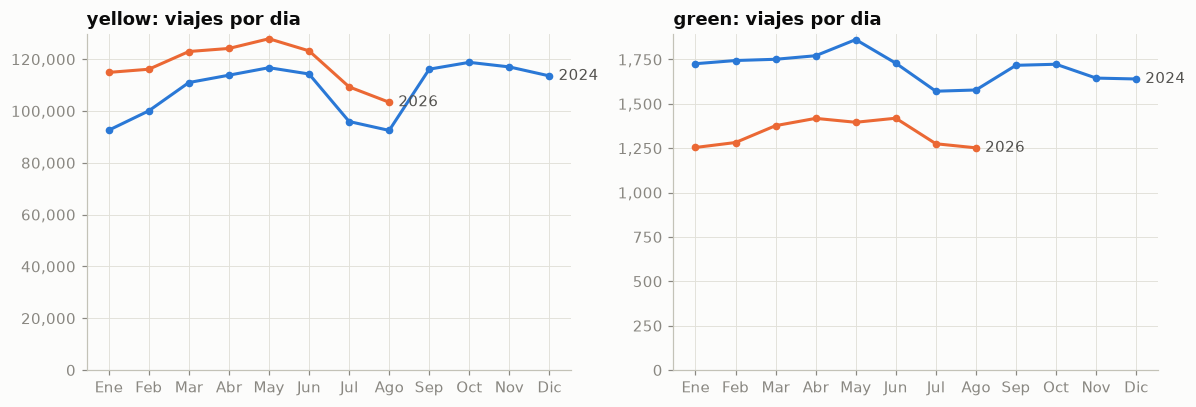

In [9]:
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, tipo in zip(axes, ["yellow", "green"]):
    d = df_mes[df_mes.tipo == tipo]
    for anio, g in d.groupby("anio"):
        ax.plot(g.mes, g.viajes_por_dia, color=COLORES_ANIO[anio], marker="o", markersize=4)
        ax.annotate(str(anio), (g.mes.iloc[-1], g.viajes_por_dia.iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", color="#52514e")
    ax.set_title(f"{tipo}: viajes por dia")
    ax.set_xticks(range(1, 13), MESES)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()

## 5.7 Siguen funcionando las consultas anteriores?

Se ejecutan todas las consultas de los Ejercicios 3 y 4 sobre el conjunto ampliado y se registra si terminan, cuanto tardan y si su resultado distingue el anio.

- **Ejercicio 3:** las rutas fijan `/2026/`, asi que se ejecutan tal cual (solo leen 2026) y con el glob generalizado a `/*/`. La consulta 15 (duplicados) no se ejecuta con el glob generalizado porque supera el limite de 4 GB de temporales (ver `docs/ejercicio5.md`); su reemplazo escalable es la consulta 07 de este ejercicio.
- **Ejercicio 4:** las vistas ya leen `data/raw/<tipo>/*/`, asi que se ejecutan sin cambios.

In [10]:
def probar(sql: str) -> dict:
    inicio = time.perf_counter()
    try:
        df = con.sql(sql).df()
        return {"estado": "ok", "seg": round(time.perf_counter() - inicio, 1), "filas": len(df),
                "distingue_anio": "anio" in df.columns}
    except duckdb.Error as error:
        return {"estado": f"error: {str(error)[:60]}", "seg": round(time.perf_counter() - inicio, 1),
                "filas": None, "distingue_anio": None}


filas = []
for archivo in sorted(Path("sql/ejercicio3").glob("*.sql")):
    sql = archivo.read_text()
    tal_cual = probar(sql)
    generalizado = (probar(sql.replace("/2026/", "/*/")) if archivo.stem != "15_duplicados"
                    else {"estado": "omitida (ver 07)", "seg": None, "filas": None})
    filas.append({"consulta": archivo.stem, "rutas_con_2026": len(re.findall("/2026/", sql)),
                  "tal_cual": tal_cual["estado"], "seg": tal_cual["seg"],
                  "glob_generalizado": generalizado["estado"], "seg_generalizado": generalizado["seg"]})
pd.DataFrame(filas)

,consulta,rutas_con_2026,tal_cual,seg,glob_generalizado,seg_generalizado
0,01_conteo_archivos,1,ok,0.0,ok,0.1
1,02_registros_metadata,1,ok,0.1,ok,0.1
2,03_registros_conteo,2,ok,0.3,ok,0.9
3,04_columnas_yellow,1,ok,0.1,ok,0.1
4,05_columnas_green,1,ok,0.0,ok,0.1
5,06_comparacion_columnas,1,ok,0.1,ok,0.1
6,07_tipos_por_archivo,1,ok,0.1,ok,0.1
7,08_muestra_yellow,1,ok,0.4,ok,0.6
8,09_muestra_green,1,ok,0.1,ok,0.3
9,10_nulos,2,ok,1.1,ok,2.1


In [11]:
filas = []
for archivo in sorted(Path("sql/ejercicio4").glob("[0-9][0-9]_*.sql")):
    if archivo.stem.startswith("00"):
        continue
    filas.append({"consulta": archivo.stem, **probar(archivo.read_text())})
pd.DataFrame(filas)

,consulta,estado,seg,filas,distingue_anio
0,01_viajes_por_mes,ok,15.9,40,True
1,02_hora_dia_semana,ok,10.3,336,False
2,03_distribucion_viajes,ok,44.0,8,False
3,04_velocidad_por_hora,ok,20.7,48,False
4,05_pasajeros,ok,11.1,18,False
5,06_zonas_servicio,ok,13.7,20,False
6,07_top_zonas,ok,12.0,20,False
7,08_aeropuertos,ok,26.9,8,False
8,09_formas_de_pago,ok,15.9,12,False
9,10_flex_fare_mensual,ok,11.2,20,True


### 07 - Version escalable de la consulta de duplicados

In [12]:
ejecutar("07_duplicados_escalable")

-- 5.7 Version escalable de sql/ejercicio3/15_duplicados.sql
-- La original compara filas completas con SELECT DISTINCT *, lo que con 2024 y 2026
-- juntos supera la memoria y el limite de temporales. Aqui se compara un hash de
-- 64 bits de cada fila: la tabla de distintos guarda un entero por fila en lugar de
-- 20 columnas. La probabilidad de colision con ~70 millones de filas es del orden
-- de 1e-4, despreciable para contar duplicados.
SELECT regexp_extract(filename, 'raw/(\w+)/', 1) AS tipo,
       regexp_extract(filename, '/(\d{4})/', 1)::INT AS anio,
       count(*) AS registros,
       count(*) - count(DISTINCT hash(*COLUMNS(* EXCLUDE (filename)))) AS filas_duplicadas
FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
GROUP BY ALL
ORDER BY anio, tipo;



,tipo,anio,registros,filas_duplicadas
0,green,2024,660218,0
1,yellow,2024,41169720,4
2,green,2026,337114,0
3,yellow,2026,29703355,7
